In [1]:
### import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer


In [4]:
### import data
data= pd.read_csv("./brca_metabric_clinical_data.tsv", sep="\t")

In [5]:
### Feature selection

# list of features to keep
keep_columns=["Age at Diagnosis", 
              "Cancer Type Detailed", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster",
              "Overall Survival (Months)"]

# remove other features
data = data[keep_columns].copy()

# confirm removal
print(data.columns)

# remove samples where Overall Survival is NA
data = data.dropna(subset=["Overall Survival (Months)"])

Index(['Age at Diagnosis', 'Cancer Type Detailed', 'Inferred Menopausal State',
       'Tumor Size', 'Lymph nodes examined positive',
       '3-Gene classifier subtype', 'Pam50 + Claudin-low subtype',
       'Integrative Cluster', 'Overall Survival (Months)'],
      dtype='str')


In [6]:
### Group rare cancer types together

top3 = data["Cancer Type Detailed"].value_counts().nlargest(3).index

data["Cancer Type Grouped"] = data["Cancer Type Detailed"].apply(
    lambda x: x if x in top3 else "Other")

print(data["Cancer Type Grouped"].value_counts())

Cancer Type Grouped
Breast Invasive Ductal Carcinoma             1538
Breast Mixed Ductal and Lobular Carcinoma     211
Breast Invasive Lobular Carcinoma             146
Other                                          86
Name: count, dtype: int64


In [7]:
### Discretize overall survival (months) into 4 groups

for index, row in data.iterrows():
    if row["Overall Survival (Months)"]>=180:
        data.loc[index, "Survival Duration"] = "15+ years"
    elif row["Overall Survival (Months)"]>=120:
        data.loc[index, "Survival Duration"] = "10-15 years" 
    elif row["Overall Survival (Months)"]>=60:
        data.loc[index, "Survival Duration"] = "5-10 years"
    else:
        data.loc[index, "Survival Duration"] = "<5 years"

In [8]:
### split predictors and response

predictors=["Age at Diagnosis", 
              "Cancer Type Grouped", 
              "Inferred Menopausal State", 
              "Tumor Size",
              "Lymph nodes examined positive",
              "3-Gene classifier subtype",
              "Pam50 + Claudin-low subtype",
              "Integrative Cluster"]

x= data[predictors]
y= data["Survival Duration"]

In [9]:
x_encoded = pd.get_dummies(x, drop_first=True)
print(x_encoded.dtypes)

Age at Diagnosis                                                 float64
Tumor Size                                                       float64
Lymph nodes examined positive                                    float64
Cancer Type Grouped_Breast Invasive Lobular Carcinoma               bool
Cancer Type Grouped_Breast Mixed Ductal and Lobular Carcinoma       bool
Cancer Type Grouped_Other                                           bool
Inferred Menopausal State_Pre                                       bool
3-Gene classifier subtype_ER+/HER2- Low Prolif                      bool
3-Gene classifier subtype_ER-/HER2-                                 bool
3-Gene classifier subtype_HER2+                                     bool
Pam50 + Claudin-low subtype_Her2                                    bool
Pam50 + Claudin-low subtype_LumA                                    bool
Pam50 + Claudin-low subtype_LumB                                    bool
Pam50 + Claudin-low subtype_NC                     

In [10]:
print(x_encoded.isna().sum())

Age at Diagnosis                                                  0
Tumor Size                                                       26
Lymph nodes examined positive                                    76
Cancer Type Grouped_Breast Invasive Lobular Carcinoma             0
Cancer Type Grouped_Breast Mixed Ductal and Lobular Carcinoma     0
Cancer Type Grouped_Other                                         0
Inferred Menopausal State_Pre                                     0
3-Gene classifier subtype_ER+/HER2- Low Prolif                    0
3-Gene classifier subtype_ER-/HER2-                               0
3-Gene classifier subtype_HER2+                                   0
Pam50 + Claudin-low subtype_Her2                                  0
Pam50 + Claudin-low subtype_LumA                                  0
Pam50 + Claudin-low subtype_LumB                                  0
Pam50 + Claudin-low subtype_NC                                    0
Pam50 + Claudin-low subtype_Normal              

In [11]:
print(x_encoded.isna().sum().sum())

102


In [12]:
x_encoded.isna().sum().sort_values(ascending=False)

Lymph nodes examined positive                                    76
Tumor Size                                                       26
Age at Diagnosis                                                  0
Cancer Type Grouped_Breast Invasive Lobular Carcinoma             0
Cancer Type Grouped_Breast Mixed Ductal and Lobular Carcinoma     0
Cancer Type Grouped_Other                                         0
Inferred Menopausal State_Pre                                     0
3-Gene classifier subtype_ER+/HER2- Low Prolif                    0
3-Gene classifier subtype_ER-/HER2-                               0
3-Gene classifier subtype_HER2+                                   0
Pam50 + Claudin-low subtype_Her2                                  0
Pam50 + Claudin-low subtype_LumA                                  0
Pam50 + Claudin-low subtype_LumB                                  0
Pam50 + Claudin-low subtype_NC                                    0
Pam50 + Claudin-low subtype_Normal              

In [23]:
imputer = KNNImputer(n_neighbors=5)

x_imputed = pd.DataFrame(imputer.fit_transform(x_encoded), columns=x_encoded.columns)
print(x_imputed.isna().sum().sum())

0


In [ ]:
### split into test and train data 
x_train, x_test, y_train, y_test = train_test_split(
    x_imputed,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42) 

In [44]:
### k-NN without scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(x_train, y_train)

knn_unscaled_train_accuracy = knn_unscaled.score(x_train, y_train)
knn_unscaled_test_accuracy = knn_unscaled.score(x_test, y_test)

print(f"Unscaled k-NN training accuracy: {knn_unscaled_train_accuracy:.3f}")
print(f"Unscaled k-NN testing accuracy:  {knn_unscaled_test_accuracy:.3f}")

Unscaled k-NN training accuracy: 0.498
Unscaled k-NN testing accuracy:  0.315


In [53]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

knn_scaled_5 = KNeighborsClassifier(n_neighbors=53)
knn_scaled_5.fit(x_train_scaled, y_train)

knn_scaled_5_train_accuracy = knn_scaled_5.score(x_train_scaled, y_train)
knn_scaled_5_test_accuracy = knn_scaled_5.score(x_test_scaled, y_test)

print(f"Scaled training shape: {x_train_scaled.shape}") 
print(f"Scaled testing shape:  {x_test_scaled.shape}")
print(f"Scaled k-NN training accuracy: {knn_scaled_5_train_accuracy:.3f}")
print(f"Scaled k-NN testing accuracy:  {knn_scaled_5_test_accuracy:.3f}")
print(
    "Testing accuracy change after scaling: "
    f"{knn_scaled_5_test_accuracy - knn_unscaled_test_accuracy:+.3f}"
)

Scaled training shape: (1584, 26)
Scaled testing shape:  (397, 26)
Scaled k-NN training accuracy: 0.378
Scaled k-NN testing accuracy:  0.335
Testing accuracy change after scaling: +0.020


,k,cv_mean,cv_std
0,1,0.300,0.018
1,3,0.275,0.017
2,5,0.283,0.023
3,7,0.276,0.033
4,9,0.290,0.028
5,11,0.309,0.034
6,13,0.293,0.022
7,15,0.302,0.023
8,17,0.309,0.016
9,19,0.311,0.017


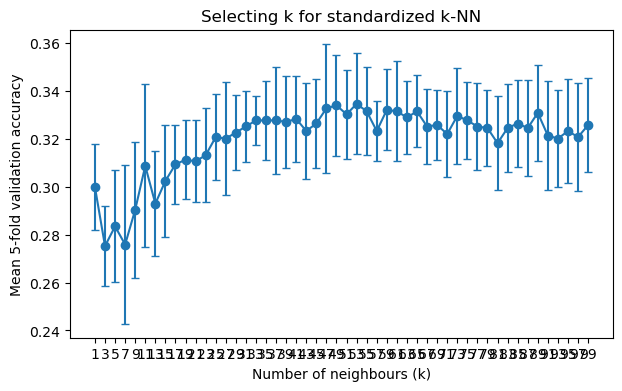

Selected k: 53
Best mean validation accuracy: 0.335
Final k-NN training accuracy: 0.378
Final k-NN testing accuracy:  0.335


In [52]:
### Choosing a value of k using cross-validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_rows = []
for k in range(1, 100, 2):
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, x_train_scaled, y_train, cv=cv, scoring="accuracy")
    k_rows.append({
        "k": k,
        "cv_mean": scores.mean(),
        "cv_std": scores.std()
    })

k_results = pd.DataFrame(k_rows)
display(k_results.round(3))

plt.figure(figsize=(7, 4))
plt.errorbar(
    k_results["k"],
    k_results["cv_mean"],
    yerr=k_results["cv_std"],
    marker="o",
    capsize=3
)
plt.xlabel("Number of neighbours (k)")
plt.ylabel("Mean 5-fold validation accuracy")
plt.title("Selecting k for standardized k-NN")
plt.xticks(k_results["k"])
plt.show()

best_row = k_results.loc[k_results["cv_mean"].idxmax()]
best_k = int(best_row["k"])
print(f"Selected k: {best_k}")
print(f"Best mean validation accuracy: {best_row['cv_mean']:.3f}")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(x_train_scaled, y_train)
knn_train_accuracy = knn_final.score(x_train_scaled, y_train)
knn_test_accuracy = knn_final.score(x_test_scaled, y_test)

print(f"Final k-NN training accuracy: {knn_train_accuracy:.3f}")
print(f"Final k-NN testing accuracy:  {knn_test_accuracy:.3f}")